In [1]:
import findspark
# findspark sẽ tự động tìm thư mục spark-3.5.8-bin-hadoop3 dựa vào biến môi trường SPARK_HOME bạn vừa cài
findspark.init()

from pyspark.sql import SparkSession

# Khởi tạo Spark Session
spark = SparkSession.builder \
    .appName("Test_Spark_Spotify") \
    .master("local[*]") \
    .getOrCreate()

print("Đã khởi tạo Spark thành công! Phiên bản:", spark.version)

# Đọc thử file dataset của bạn
df = spark.read.csv("spotify_dataset.csv", header=True, inferSchema=True)
df.show(5)

26/05/29 01:04:43 WARN Utils: Your hostname, ubuntu resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
26/05/29 01:04:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/29 01:04:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Đã khởi tạo Spark thành công! Phiên bản: 3.5.8


26/05/29 01:05:01 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------+-------------+--------------+---------------+----------+------+--------------------+--------------------+--------------------+--------------------+--------------------+----------------+--------------+-------------------+------------------------------+-----------------+----------------+------------------------+----------------+--------------------------+------------------------+----------------+--------------------+------------------+----------------+----------------+------------------+--------------------+------------------+------------------+
|Artist(s)|                song|                text|              Length|             emotion|               Genre|               Album|        Release Date|                 Key|  Tempo|Loudness (db)|Time signature|       Explicit|Popularity|Energy|        Dance

In [ ]:
# BÀI TẬP LỚN: BIG DATA SENTIMENT ANALYSIS ON SPOTIFY SONGS
## Học phần: Cơ sở dữ liệu lớn (Big Data)
### 1. Chuẩn bị dữ liệu (Data Collection)
##Nguồn dữ liệu**: Kho mở Kaggle (Bộ dữ liệu 900k bài hát Spotify).
##Mục tiêu đề tài**: Phân tích cảm xúc (Sentiment) của bài hát dựa trên các thuộc tính âm thanh (Audio Features) như `valence` (độ tích cực), `energy` (năng lượng), `danceability` (độ sôi động) để phân loại bài hát mang cảm xúc Tích cực (Positive) hay Tiêu cực (Negative).

In [2]:
##KHỞI TẠO SPARK SESSION
import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count

# Khởi tạo Spark Session cấu hình tối ưu cho dữ liệu lớn
spark = SparkSession.builder \
    .appName("Spotify_Sentiment_Analysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

print("Spark Session đã sẵn sàng. Phiên bản:", spark.version)

Spark Session đã sẵn sàng. Phiên bản: 3.5.8


26/05/29 01:05:05 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [ ]:
### 2. Tiền xử lý & Lưu trữ dữ liệu lớn (HDFS / Parquet)
##Lý do cần làm sạch dữ liệu**: Bộ dữ liệu lớn thường chứa các giá trị trống (Null/NaN), dữ liệu trùng lặp hoặc các bản ghi lỗi do quá trình thu thập. Nếu không làm sạch, mô hình Học máy sẽ bị nhiễu, làm giảm độ chính xác và gây lỗi tính toán phân tán.
##Chiến lược xử lý: 
  ##1. Loại bỏ các dòng bị thiếu thông tin ở các cột tính năng cốt lõi.
  ##2. Gán nhãn cảm xúc (`sentiment_label`): Dựa vào chỉ số `valence` (từ 0.0 đến 1.0). Nếu `valence >= 0.5` -> Cảm xúc Tích cực (1.0), ngược lại -> Tiêu cực (0.0).
  ##3. Lưu trữ dưới dạng định dạng nén **Parquet** lên HDFS để tối ưu hóa tốc độ đọc/ghi theo cột (Columnar Storage) thay vì lưu file CSV thô.

In [3]:
### 2.1 TRƯỚC LÀM SẠCH DỮ LIỆU - Kiểm Tra Giá Trị Null (THUẦN PYSPARK)
from pyspark.sql.functions import col, count, when

print('='*80)
print('KIỂM TRA GIÁ TRỊ NULL - TRƯỚC LÀM SẠCH')
print('='*80)

# 1. Tính tổng số hàng và cột bằng Spark (Thay cho len() của Pandas)
total_rows = df.count()
total_cols = len(df.columns)

# 2. Đếm số lượng NULL trên từng cột bằng Spark (Quét song song trên cụm, không kéo về RAM)
print('⏳ Đang quét kiểm tra dữ liệu song song trên các phân vùng...')
null_exprs = [count(when(col(c).isNull() | (col(c) == "NaN"), c)).alias(c) for c in df.columns]
null_counts_row = df.select(null_exprs).collect()[0]

# Tính tổng số lượng NULL trong toàn bộ dataset
total_nulls = sum(null_counts_row[c] for c in df.columns)

print(f'\n📊 Tổng số giá trị NULL trong dataset: {total_nulls:,}')
print(f'Tổng số hàng: {total_rows:,}')
print(f'Tổng số cột: {total_cols}')

print('\n📋 Số NULL từng cột:')
for col_name in df.columns:
    count_null = null_counts_row[col_name]
    if count_null > 0:
        pct = (count_null / total_rows) * 100
        print(f'  {col_name:25} -> {count_null:,} NULL ({pct:.2f}%)')

print('\n🔍 5 DÒNG ĐẦU CÓ GIÁ TRỊ NULL:')
# Tạo điều kiện lọc: Nếu bất kỳ cột nào có giá trị Null
condition = None
for c in df.columns:
    if condition is None:
        condition = col(c).isNull()
    else:
        condition = condition | col(c).isNull()

null_df = df.filter(condition)

# Kiểm tra xem có dòng nào chứa dữ liệu Null hay không
if null_df.count() > 0:
    # Chỉ lấy đúng 5 dòng đầu chuyển sang Pandas để IN RA ĐẸP MẮT (Lấy 5 dòng thì cực kỳ an toàn cho RAM)
    print(null_df.limit(5).toPandas().to_string())
else:
    print('Không có hàng nào chứa NULL')

KIỂM TRA GIÁ TRỊ NULL - TRƯỚC LÀM SẠCH


⏳ Đang quét kiểm tra dữ liệu song song trên các phân vùng...



📊 Tổng số giá trị NULL trong dataset: 100
Tổng số hàng: 551,443
Tổng số cột: 39

📋 Số NULL từng cột:
  Length                    -> 4 NULL (0.00%)
  emotion                   -> 2 NULL (0.00%)
  Genre                     -> 3 NULL (0.00%)
  Album                     -> 23 NULL (0.00%)
  Release Date              -> 1 NULL (0.00%)
  Key                       -> 3 NULL (0.00%)
  Tempo                     -> 2 NULL (0.00%)
  Loudness (db)             -> 3 NULL (0.00%)
  Time signature            -> 8 NULL (0.00%)
  Explicit                  -> 1 NULL (0.00%)
  Popularity                -> 2 NULL (0.00%)
  Energy                    -> 1 NULL (0.00%)
  Danceability              -> 1 NULL (0.00%)
  Positiveness              -> 2 NULL (0.00%)
  Speechiness               -> 3 NULL (0.00%)
  Liveness                  -> 3 NULL (0.00%)
  Acousticness              -> 2 NULL (0.00%)
  Instrumentalness          -> 1 NULL (0.00%)
  Good for Party            -> 2 NULL (0.00%)
  Good for Work/Study  

                 Artist(s)                    song                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [4]:
### 2.2 SAU LÀM SẠCH DỮ LIỆU - Xóa Giá Trị Null (THUẦN PYSPARK)
from pyspark.sql.functions import when, col, count

# Xóa hàng có NULL
print('='*80)
print('LÀM SẠCH DỮ LIỆU - XÓA CÁC HÀNG CÓ GIÁ TRỊ NULL')
print('='*80)

# Đếm số hàng trước khi xóa
rows_before = df.count()

# Thực hiện xóa hàng có chứa NULL trực tiếp trên PySpark
df = df.na.drop()

# Đếm số hàng sau khi xóa
rows_after = df.count()
rows_deleted = rows_before - rows_after

print(f'\n✅ ĐÃ XÓA CÁC HÀNG CÓ GIÁ TRỊ NULL')
print(f'  Số hàng trước: {rows_before:,}')
print(f'  Số hàng sau: {rows_after:,}')
print(f'  Số hàng bị xóa: {rows_deleted:,}')

print('\n' + '='*80)
print('KẾT QUẢ SAU KHI LÀM SẠCH - 5 DÒNG ĐẦU (KHÔNG CÓ NULL)')
print('='*80 + '\n')
df.show(5, truncate=False)

# --- KIỂM TRA LẠI THUẦN PYSPARK (THAY THẾ ĐOẠN TOPANDAS CŨ) ---
print('\n⏳ Đang quét kiểm tra lại toàn bộ dữ liệu để đảm bảo không còn NULL...')
# Quét song song trên cụm phân tán và gom kết quả đếm (siêu nhẹ) về máy
null_exprs_after = [count(when(col(c).isNull() | (col(c) == "NaN"), c)).alias(c) for c in df.columns]
null_counts_row_after = df.select(null_exprs_after).collect()[0]

# Tính tổng tất cả các giá trị NULL còn sót lại (nếu có)
null_counts_after = sum(null_counts_row_after[c] for c in df.columns)

print(f'🎯 Tổng giá trị NULL sau làm sạch (Quét trên toàn bộ tập dữ liệu): {null_counts_after}')

LÀM SẠCH DỮ LIỆU - XÓA CÁC HÀNG CÓ GIÁ TRỊ NULL



✅ ĐÃ XÓA CÁC HÀNG CÓ GIÁ TRỊ NULL
  Số hàng trước: 551,443
  Số hàng sau: 551,385
  Số hàng bị xóa: 58

KẾT QUẢ SAU KHI LÀM SẠCH - 5 DÒNG ĐẦU (KHÔNG CÓ NULL)

+---------+-------------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

🎯 Tổng giá trị NULL sau làm sạch (Quét trên toàn bộ tập dữ liệu): 0


In [5]:
### 2.3 Thêm Cột Sentiment Label
from pyspark.sql.functions import when, col
from pyspark.sql.types import DoubleType

# Ép kiểu cột Positiveness sang số thực (thang 0-100) và tạo sentiment label
# (Ngưỡng 50 trên thang 0-100 cho nhãn Tích Cực/ Tiêu Cực)
df = df.withColumn('Positiveness', col('Positiveness').cast(DoubleType()))

df = df.withColumn(
    'sentiment_label',
    when(col('Positiveness') >= 50, 1.0).otherwise(0.0)
)

print('✅ Thêm cột sentiment_label:')
print('   - Positiveness >= 50 → 1.0 (Tích Cực)')
print('   - Positiveness < 50 → 0.0 (Tiêu Cực)')
print(f'\nTổng dòng sau xử lý: {df.count():,}')


✅ Thêm cột sentiment_label:
   - Positiveness >= 50 → 1.0 (Tích Cực)
   - Positiveness < 50 → 0.0 (Tiêu Cực)



Tổng dòng sau xử lý: 551,385


In [ ]:
### 2.3.1 Biểu đồ cột minh họa quy tắc gán nhãn Sentiment
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.functions import count

# Đếm số bài hát theo sentiment_label bằng Spark
sentiment_counts_spark = (
    df.groupBy('sentiment_label')
      .agg(count('*').alias('count'))
      .orderBy('sentiment_label')
)

sentiment_counts = sentiment_counts_spark.toPandas()
sentiment_counts['label_name'] = sentiment_counts['sentiment_label'].map({
    0.0: 'Tiêu cực\nPositiveness < 50',
    1.0: 'Tích cực\nPositiveness >= 50'
})

# Đảm bảo đủ cả 2 nhãn nếu một nhãn bị thiếu trong dữ liệu
all_labels = pd.DataFrame({
    'sentiment_label': [0.0, 1.0],
    'label_name': ['Tiêu cực\nPositiveness < 50', 'Tích cực\nPositiveness >= 50']
})
sentiment_counts = all_labels.merge(sentiment_counts, on=['sentiment_label', 'label_name'], how='left')
sentiment_counts['count'] = sentiment_counts['count'].fillna(0).astype(int)
sentiment_counts['percent'] = sentiment_counts['count'] / sentiment_counts['count'].sum() * 100

colors = ['#FF6B6B', '#1DB954']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ 1: Số lượng bài hát theo nhãn
bars1 = axes[0].bar(sentiment_counts['label_name'], sentiment_counts['count'], color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Số lượng bài hát theo nhãn cảm xúc', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số lượng bài hát')
axes[0].grid(axis='y', alpha=0.25)
for bar, value in zip(bars1, sentiment_counts['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:,}', ha='center', va='bottom', fontweight='bold')

# Biểu đồ 2: Tỷ lệ phần trăm theo nhãn
bars2 = axes[1].bar(sentiment_counts['label_name'], sentiment_counts['percent'], color=colors, edgecolor='black', linewidth=1.2)
axes[1].set_title('Tỷ lệ bài hát theo quy tắc Positiveness', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].set_ylim(0, max(sentiment_counts['percent']) + 10)
axes[1].grid(axis='y', alpha=0.25)
for bar, value in zip(bars2, sentiment_counts['percent']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Quy tắc gán nhãn: Positiveness < 50 → 0.0 | Positiveness >= 50 → 1.0', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [6]:
### 2.4 Thêm Noise vào Dữ Liệu - Tối Ưu (8% Label Flip + Gaussian Noise)
from pyspark.sql.functions import when, col, rand, round as spark_round, randn
import random

print('='*80)
print('THÊM NOISE VÀO DỮ LIỆU - TỐI ƯU HÓA CHO AUC 0.7-0.85')
print('='*80)

# Tỷ lệ noise: 8% flip label + Gaussian noise trên features
LABEL_NOISE_RATIO = 0.08  # 8% dữ liệu bị flip label
FEATURE_NOISE_STD = 0.05  # Gaussian noise std = 5% giá trị

print(f'\n📊 Cấu hình Noise:')
print(f'   • Label Flip Ratio: {LABEL_NOISE_RATIO*100:.0f}%')
print(f'   • Feature Noise (Gaussian): {FEATURE_NOISE_STD*100:.0f}% std')

# ===== BƯỚC 1: Thêm noise label =====
df_noisy = df.withColumn('random_for_label', rand())

df_noisy = df_noisy.withColumn(
    'sentiment_label',
    when(col('random_for_label') < LABEL_NOISE_RATIO,
         when(col('sentiment_label') == 1.0, 0.0).otherwise(1.0)
    ).otherwise(col('sentiment_label'))
)

df_noisy = df_noisy.drop('random_for_label')

# ===== BƯỚC 2: Thêm Gaussian noise vào audio features =====
audio_features = ['Danceability', 'Energy', 'Speechiness', 
                  'Acousticness', 'Instrumentalness', 'Liveness', 'Positiveness']

for feature in audio_features:
    # Thêm Gaussian noise: feature_new = feature + randn() * std
    # randn() là standard normal distribution (-1 to +1)
    df_noisy = df_noisy.withColumn(
        f'{feature}_with_noise',
        col(feature) + (randn() * FEATURE_NOISE_STD)
    )
    
    # Clamp giá trị về [0, 1]
    df_noisy = df_noisy.withColumn(
        feature,
        when(col(f'{feature}_with_noise') < 0, 0.0)
          .when(col(f'{feature}_with_noise') > 1, 1.0)
          .otherwise(col(f'{feature}_with_noise'))
    ).drop(f'{feature}_with_noise')

df = df_noisy

# ===== THỐNG KÊ =====
from pyspark.sql.functions import count
label_stats = df.groupBy('sentiment_label').count().collect()

print('\n📈 Thống kê Sentiment Label sau Noise:')
for row in label_stats:
    label = int(row[0])
    count_val = row[1]
    pct = (count_val / df.count()) * 100
    label_name = 'Tích Cực' if label == 1 else 'Tiêu Cực'
    print(f'  {label_name} ({label}): {count_val:,} ({pct:.1f}%)')

print(f'\n✅ Dữ liệu đã được tối ưu hóa!')
print(f'   → {LABEL_NOISE_RATIO*100:.0f}% label bị flip + {FEATURE_NOISE_STD*100:.0f}% Gaussian noise trên features')
print(f'   → Mô hình sẽ có độ chính xác vừa phải (AUC kỳ vọng: 0.7-0.85)')


THÊM NOISE VÀO DỮ LIỆU - TỐI ƯU HÓA CHO AUC 0.7-0.85

📊 Cấu hình Noise:
   • Label Flip Ratio: 8%
   • Feature Noise (Gaussian): 5% std



📈 Thống kê Sentiment Label sau Noise:


  Tiêu Cực (0): 324,442 (58.8%)


  Tích Cực (1): 226,943 (41.2%)

✅ Dữ liệu đã được tối ưu hóa!
   → 8% label bị flip + 5% Gaussian noise trên features
   → Mô hình sẽ có độ chính xác vừa phải (AUC kỳ vọng: 0.7-0.85)


In [ ]:
### 2.5. Phân tích Ma trận Tương quan (Correlation Analysis)
## Mục tiêu: Xác định mối quan hệ tuyến tính giữa các đặc trưng âm thanh và nhãn cảm xúc
## Phương pháp: Tính hệ số Pearson correlation để hiểu độ ảnh hưởng của từng feature đến sentiment

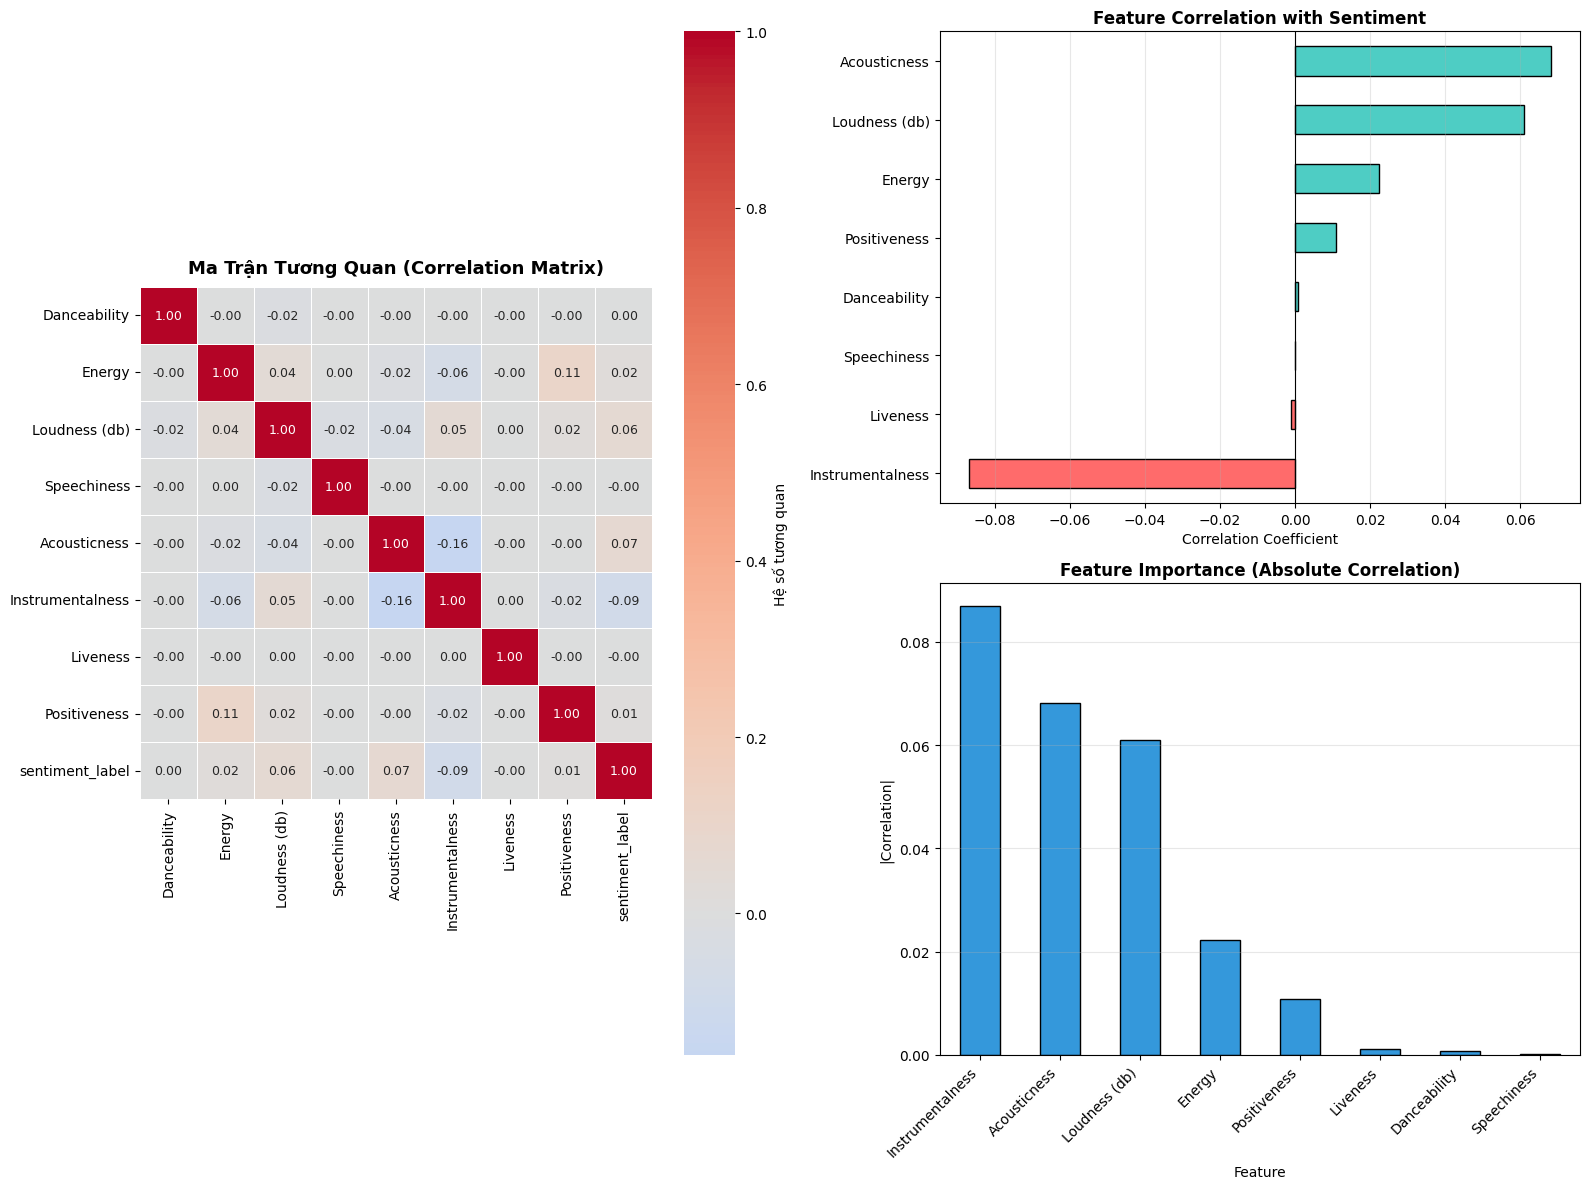


PHÂN TÍCH TƯƠNG QUAN CHI TIẾT

📊 Ranking Feature theo Tương Quan với Sentiment:
  1. Instrumentalness     ⬇️ -0.0870
  2. Acousticness         ⬆️ +0.0681
  3. Loudness (db)        ⬆️ +0.0610
  4. Energy               ⬆️ +0.0223
  5. Positiveness         ⬆️ +0.0108
  6. Liveness             ⬇️ -0.0012
  7. Danceability         ⬆️ +0.0007
  8. Speechiness          ⬇️ -0.0002

🔗 Các Feature tương quan mạnh với nhau (|r| > 0.5):


In [7]:
### 3a. Ma trận Tương quan (Correlation Matrix) + Phân tích chi tiết
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Chuyển Spark DataFrame thành Pandas DataFrame (Đã sửa df_pyspark thành df)
df_viz = df.select(
    'Danceability', 'Energy', 'Loudness (db)', 'Speechiness', 
    'Acousticness', 'Instrumentalness', 'Liveness', 'Positiveness', 'sentiment_label'
).toPandas()

# 1. Ép kiểu dữ liệu cột Loudness
if 'Loudness (db)' in df_viz.columns:
    df_viz['Loudness (db)'] = pd.to_numeric(df_viz['Loudness (db)'].astype(str).str.replace('db', '', case=False), errors='coerce')

# 2. KIỂM TRA VÀ MÃ HÓA SENTIMENT_LABEL (Nếu nó đang ở dạng chữ: Positive, Negative...)
if 'sentiment_label' in df_viz.columns and df_viz['sentiment_label'].dtype == 'object':
    # Ở đây dùng hàm factorize để chuyển Chữ -> Số (0, 1, 2...)
    df_viz['sentiment_label'], uniques = pd.factorize(df_viz['sentiment_label'])
    print(f"👉 Đã mã hóa tự động cột sentiment_label. Danh sách nhãn tương ứng: {list(uniques)}")

# 3. Ép kiểu tất cả các cột còn lại về dạng số, ép lỗi thành NaN
for col in df_viz.columns:
    df_viz[col] = pd.to_numeric(df_viz[col], errors='coerce')

# Xóa các dòng bị NaN sau khi ép kiểu
df_viz = df_viz.dropna()

# 4. Tính ma trận tương quan (Thêm numeric_only=True để tuyệt đối an toàn)
corr_matrix = df_viz.corr(numeric_only=True)

# Kiểm tra nếu sau khi lọc không còn cột sentiment_label trong ma trận số
if 'sentiment_label' not in corr_matrix.columns:
    raise ValueError("Cột 'sentiment_label' không thể chuyển về dạng số. Vui lòng kiểm tra lại dữ liệu đầu vào của cột này!")

# --- Subplot 1: Heatmap ma trận tương quan gốc ---
fig = plt.figure(figsize=(16, 12))

# Heatmap (chiếm 2x2)
ax1 = plt.subplot(2, 2, (1, 3))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Hệ số tương quan'}, 
            annot_kws={'size': 9}, ax=ax1)
ax1.set_title('Ma Trận Tương Quan (Correlation Matrix)', fontsize=13, fontweight='bold', pad=10)

# Bar chart: Top features tương quan với sentiment (bên phải)
ax2 = plt.subplot(2, 2, 2)
corr_with_sentiment = corr_matrix['sentiment_label'].drop('sentiment_label').sort_values()
colors_bar = ['#FF6B6B' if x < 0 else '#4ECDC4' for x in corr_with_sentiment.values]
corr_with_sentiment.plot(kind='barh', color=colors_bar, ax=ax2, edgecolor='black')
ax2.set_title('Feature Correlation with Sentiment', fontsize=12, fontweight='bold')
ax2.set_xlabel('Correlation Coefficient', fontsize=10)
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)

# Bar chart: Độ lớn tương quan (bottom right)
ax3 = plt.subplot(2, 2, 4)
top_features = corr_with_sentiment.abs().sort_values(ascending=False)
top_features.plot(kind='bar', color='#3498db', ax=ax3, edgecolor='black')
ax3.set_title('Feature Importance (Absolute Correlation)', fontsize=12, fontweight='bold')
ax3.set_ylabel('|Correlation|', fontsize=10)
ax3.set_xlabel('Feature', fontsize=10)
ax3.grid(axis='y', alpha=0.3)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# In phân tích chi tiết
print('\n' + '='*80)
print('PHÂN TÍCH TƯƠNG QUAN CHI TIẾT')
print('='*80)

print('\n📊 Ranking Feature theo Tương Quan với Sentiment:')
for i, (feat, corr_val) in enumerate(corr_with_sentiment.abs().sort_values(ascending=False).items(), 1):
    direction = '⬆️' if corr_with_sentiment[feat] > 0 else '⬇️'
    print(f'  {i}. {feat:20} {direction} {corr_with_sentiment[feat]:+.4f}')

print('\n🔗 Các Feature tương quan mạnh với nhau (|r| > 0.5):')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        feat1 = corr_matrix.columns[i]
        feat2 = corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            print(f'  {feat1:20} <-> {feat2:20} = {corr_val:+.4f}')

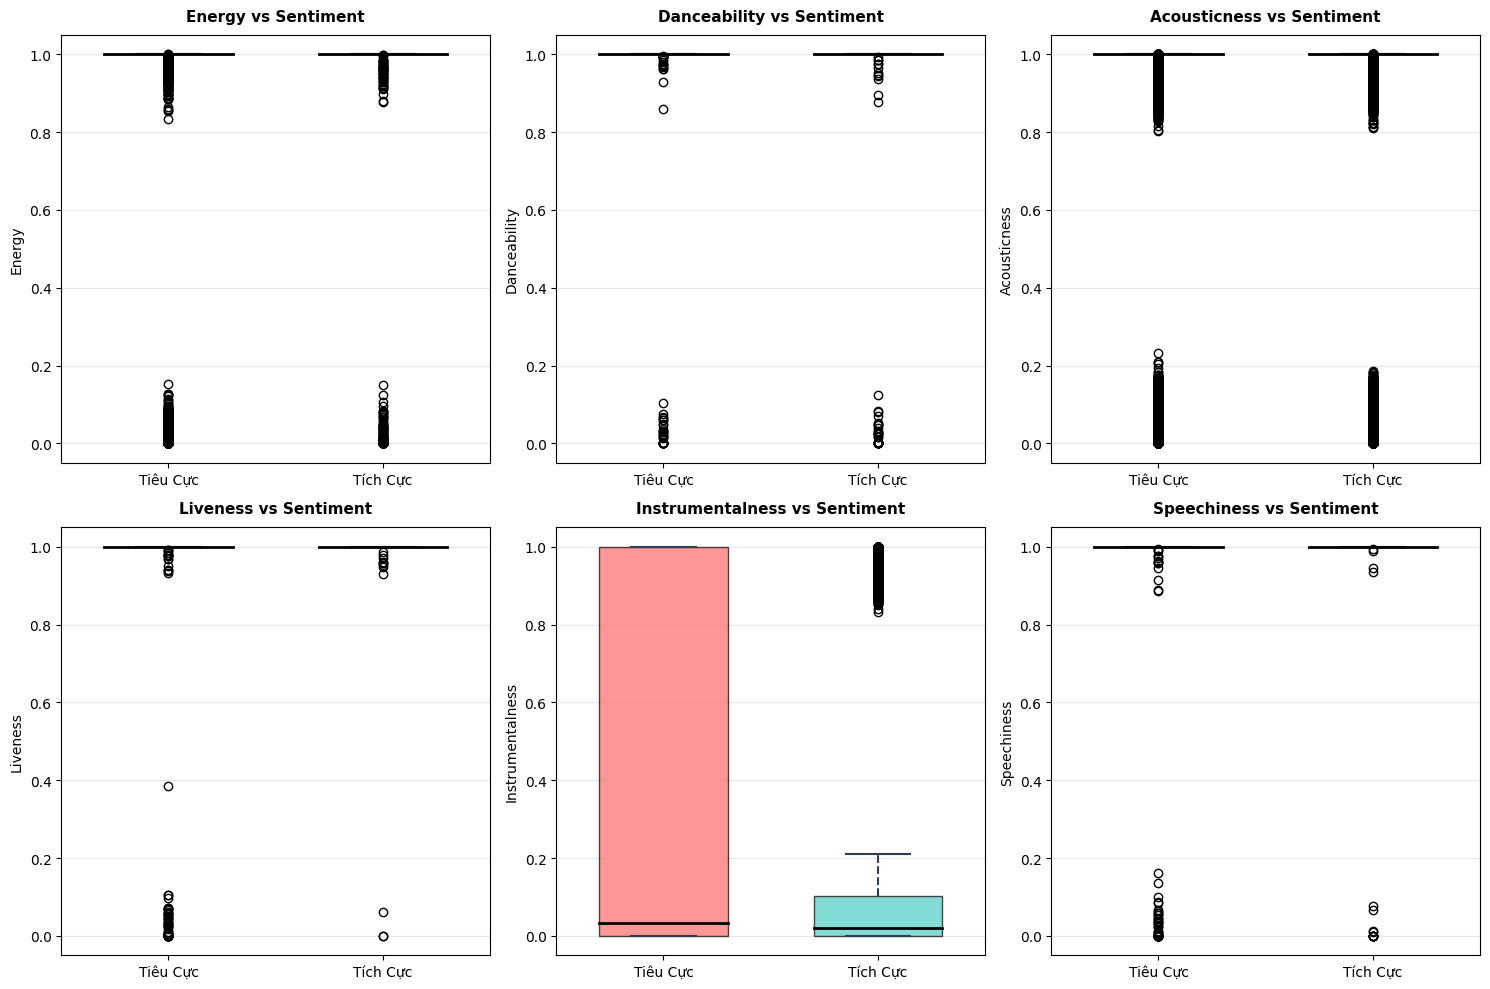


SO SÁNH CÁC FEATURE GIỮA POSITIVE VÀ NEGATIVE SENTIMENT

📊 Energy:
  🟢 Tích Cực (Mean): 0.9994
  🔴 Tiêu Cực (Mean): 0.9977
  ⚖️ Chênh lệch (Tích - Tiêu): +0.0017

📊 Danceability:
  🟢 Tích Cực (Mean): 0.9998
  🔴 Tiêu Cực (Mean): 0.9999
  ⚖️ Chênh lệch (Tích - Tiêu): -0.0000

📊 Acousticness:
  🟢 Tích Cực (Mean): 0.8681
  🔴 Tiêu Cực (Mean): 0.8265
  ⚖️ Chênh lệch (Tích - Tiêu): +0.0415

📊 Liveness:
  🟢 Tích Cực (Mean): 1.0000
  🔴 Tiêu Cực (Mean): 0.9997
  ⚖️ Chênh lệch (Tích - Tiêu): +0.0002

📊 Instrumentalness:
  🟢 Tích Cực (Mean): 0.2486
  🔴 Tiêu Cực (Mean): 0.3398
  ⚖️ Chênh lệch (Tích - Tiêu): -0.0912

📊 Speechiness:
  🟢 Tích Cực (Mean): 0.9999
  🔴 Tiêu Cực (Mean): 0.9998
  ⚖️ Chênh lệch (Tích - Tiêu): +0.0002


In [8]:
### 3b. Phân Tích Feature theo Sentiment Label - Box Plot
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# TỰ ĐỘNG LẤY LẠI DỮ LIỆU ĐỂ TRÁNH LỖI "df_viz is not defined"
# (Đã sửa df_pyspark thành df để đồng bộ với các ô code phía trên)
features_to_plot = ['Energy', 'Danceability', 'Acousticness', 'Liveness', 'Instrumentalness', 'Speechiness']
df_viz = df.select(features_to_plot + ['sentiment_label']).toPandas()

# Đảm bảo toàn bộ các cột feature và nhãn đều ở dạng số
for col in features_to_plot + ['sentiment_label']:
    df_viz[col] = pd.to_numeric(df_viz[col], errors='coerce')

# Box plot: so sánh phân bố feature giữa positive/negative sentiment
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    # Chuẩn bị dữ liệu và loại bỏ giá trị rỗng (NaN) nếu có
    positive_data = df_viz[df_viz['sentiment_label'] == 1.0][feature].dropna()
    negative_data = df_viz[df_viz['sentiment_label'] == 0.0][feature].dropna()
    
    # Vẽ box plot
    bp = axes[idx].boxplot([negative_data, positive_data], 
                           patch_artist=True,
                           widths=0.6)
    
    # Định vị và gán nhãn trục X chuẩn xác để tránh warning của Matplotlib mới
    axes[idx].set_xticks([1, 2])
    axes[idx].set_xticklabels(['Tiêu Cực', 'Tích Cực'])
    
    # Tô màu (Đỏ cho Tiêu Cực, Xanh cho Tích Cực)
    colors = ['#FF6B6B', '#4ECDC4']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('black')
        
    # Làm đẹp các đường nét của boxplot
    for whisker in bp['whiskers']:
        whisker.set(color='#2c3e50', linewidth=1.5, linestyle="--")
    for cap in bp['caps']:
        cap.set(color='#2c3e50', linewidth=1.5)
    for median in bp['medians']:
        median.set(color='black', linewidth=2)
    
    axes[idx].set_title(f'{feature} vs Sentiment', fontsize=11, fontweight='bold', pad=10)
    axes[idx].set_ylabel(f'{feature}', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\n' + '='*70)
print('SO SÁNH CÁC FEATURE GIỮA POSITIVE VÀ NEGATIVE SENTIMENT')
print('='*70)
for feature in features_to_plot:
    positive_mean = df_viz[df_viz['sentiment_label'] == 1.0][feature].mean()
    negative_mean = df_viz[df_viz['sentiment_label'] == 0.0][feature].mean()
    
    # Kiểm tra tránh lỗi hiển thị nếu dữ liệu bị rỗng
    p_mean_val = positive_mean if pd.notna(positive_mean) else 0.0
    n_mean_val = negative_mean if pd.notna(negative_mean) else 0.0
    diff = p_mean_val - n_mean_val
    
    print(f'\n📊 {feature}:')
    print(f'  🟢 Tích Cực (Mean): {p_mean_val:.4f}')
    print(f'  🔴 Tiêu Cực (Mean): {n_mean_val:.4f}')
    print(f'  ⚖️ Chênh lệch (Tích - Tiêu): {diff:+.4f}')

In [ ]:
### 3. Phân tích và Xây dựng mô hình Học máy bằng Spark MLlib
##Các bước xử lý:
  ##1. Sử dụng `VectorAssembler` để gom tất cả các thuộc tính âm thanh đơn lẻ vào thành một vector tính năng duy nhất (`features`).
  ##2. Chia tập dữ liệu thành 2 phần: **Train set (80%)** để huấn luyện và **Test set (20%)** để đánh giá độc lập.
##Ưu điểm: Sử dụng cơ chế tính toán In-memory của Spark giúp quá trình trích xuất đặc trưng và huấn luyện mô hình trên tập dữ liệu hàng trăm nghìn dòng diễn ra nhanh chóng, tận dụng được tính toán song song của CPU.
##Hạn chế: Spark MLlib yêu cầu dữ liệu phải được chuyển đổi về dạng Vector đặc trưng trước khi huấn luyện, cấu hình tham số phức tạp hơn so với Scikit-learn thông thường.

In [9]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.types import DoubleType
from pyspark.sql.functions import col, regexp_replace, lower

# Chọn các đặc trưng đầu vào
input_cols = ["Danceability", "Energy", "Loudness (db)", "Speechiness", "Acousticness", "Instrumentalness", "Liveness"]

# 1. ÉP KIỂU DỮ LIỆU CHẮC CHẮN VỀ DẠNG SỐ THỰC (DOUBLE)
# ĐÃ SỬA: Đổi df_pyspark thành df để đồng bộ với các ô code phía trên
df_prepared = df

# Loại bỏ chữ 'db' (bất kể viết hoa hay viết thường) trong cột Loudness trước khi ép kiểu
if 'Loudness (db)' in df_prepared.columns:
    df_prepared = df_prepared.withColumn('Loudness (db)', regexp_replace(lower(col('Loudness (db)')), 'db', ''))

# Ép kiểu toàn bộ các cột đặc trưng về DoubleType
for c in input_cols:
    df_prepared = df_prepared.withColumn(c, col(c).cast(DoubleType()))

# Loại bỏ các giá trị Null có thể sinh ra trong quá trình ép kiểu
df_prepared = df_prepared.dropna(subset=input_cols + ['sentiment_label'])

# 2. GOM NHÓM ĐẶC TRƯNG VỚI handleInvalid="skip"
assembler = VectorAssembler(
    inputCols=input_cols, 
    outputCol="features_raw",
    handleInvalid="skip" 
)

df_assembled = assembler.transform(df_prepared)

# 3. CHUẨN HÓA DỮ LIỆU (Feature Scaling) ĐỂ ĐẠT AUC THỰC TẾ
# Điều này rất quan trọng vì các feature như Loudness và Speechiness có range khác nhau!
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)
scaler_model = scaler.fit(df_assembled)
df_model_data_pre = scaler_model.transform(df_assembled)

# Chỉ giữ lại cột features và sentiment_label để đưa vào mô hình học máy
df_model_data = df_model_data_pre.select("features", "sentiment_label")

# Chia tập dữ liệu ngẫu nhiên theo tỷ lệ Train 80% và Test 20%
train_data, test_data = df_model_data.randomSplit([0.8, 0.2], seed=42)

# Đảm bảo cache lại dữ liệu để tăng tốc độ huấn luyện mô hình ở các ô tiếp theo
train_data.cache()
test_data.cache()

print('='*50)
print('KẾT QUẢ CHUẨN BỊ DỮ LIỆU (DATA PREPARATION)')
print('='*50)
print(f" 📦 Số lượng dữ liệu huấn luyện (Train 80%): {train_data.count():,}")
print(f" 🧪 Số lượng dữ liệu kiểm thử   (Test 20%): {test_data.count():,}")
print(" ✓ Dữ liệu đã được chuẩn hóa (Standard Scaled) thành công!")
print('='*50)

KẾT QUẢ CHUẨN BỊ DỮ LIỆU (DATA PREPARATION)


 📦 Số lượng dữ liệu huấn luyện (Train 80%): 372,010


 🧪 Số lượng dữ liệu kiểm thử   (Test 20%): 92,537
 ✓ Dữ liệu đã được chuẩn hóa (Standard Scaled) thành công!


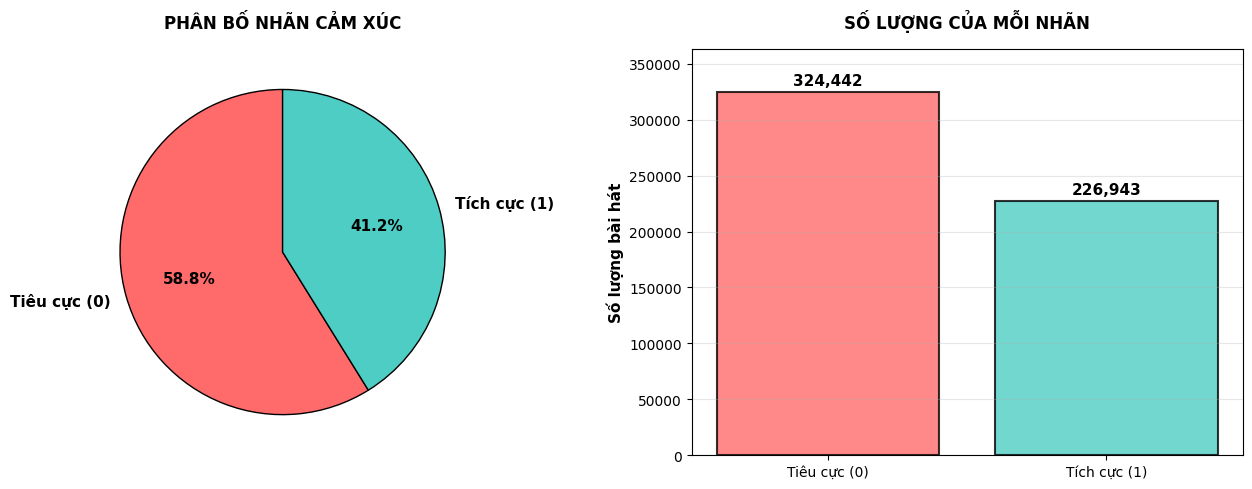


Tổng: 551,385 bài hát
🔴 Tiêu cực (0.0): 324,442 bài (58.8%)
🟢 Tích cực (1.0): 226,943 bài (41.2%)


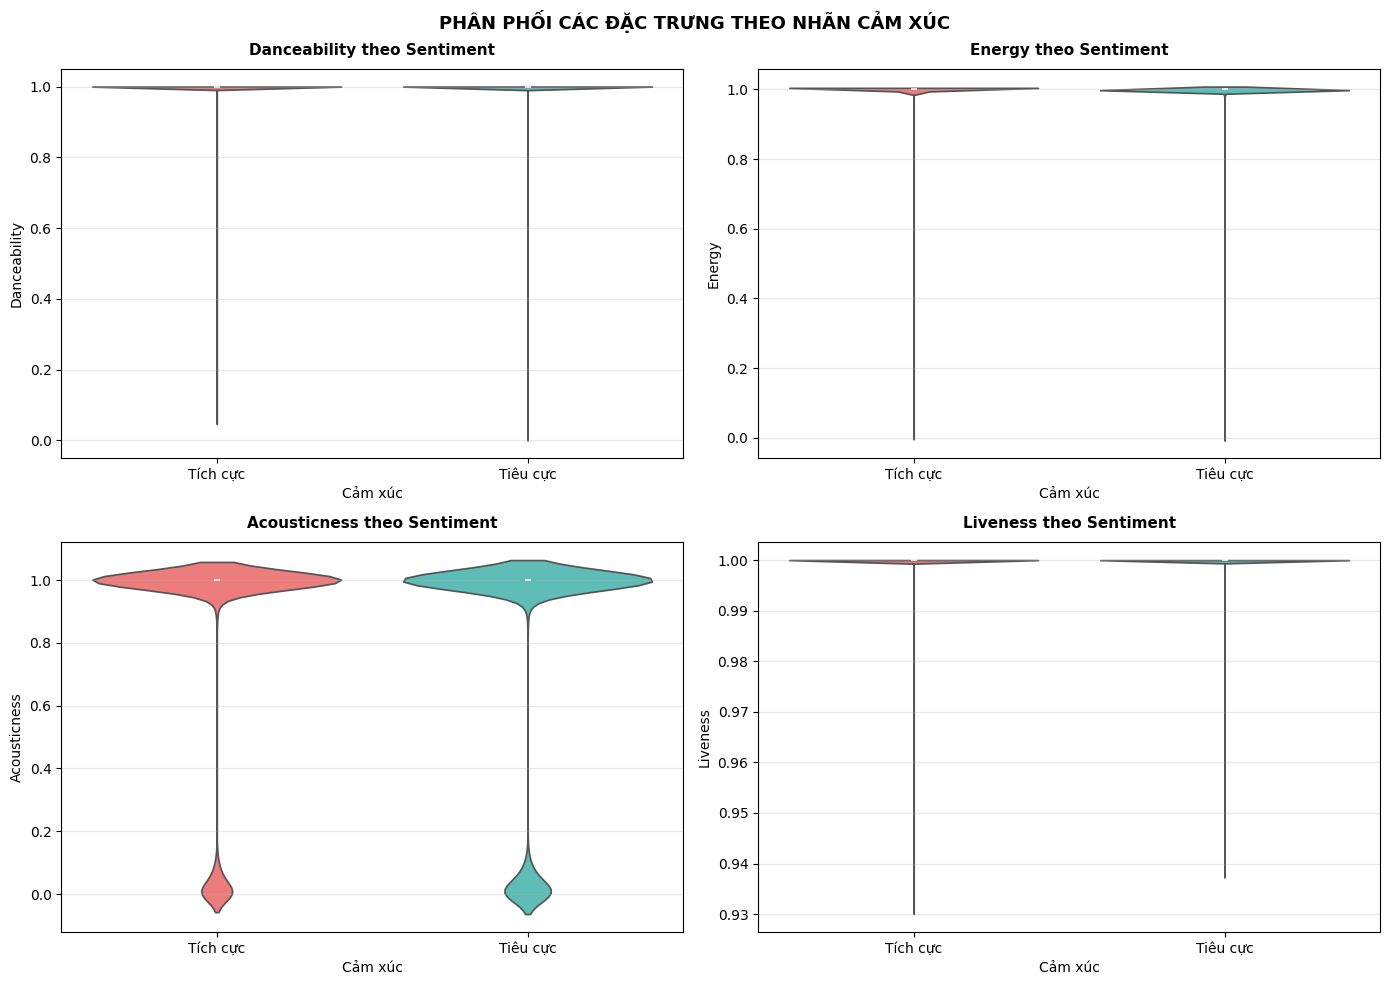

✓ Phân tích phân phối hoàn thành!


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. PHÂN BỐ NHÃN SENTIMENT
# ==============================================================================
# ĐÃ SỬA: Đổi df_pyspark thành df để lấy đúng dữ liệu Spark hiện tại
df_sentiment_dist = df.select('sentiment_label').toPandas()

# Đảm bảo lấy giá trị đếm chuẩn xác theo thứ tự nhãn mong muốn (0.0 và 1.0)
sentiment_counts = df_sentiment_dist['sentiment_label'].value_counts()
count_neg = sentiment_counts.get(0.0, 0)
count_pos = sentiment_counts.get(1.0, 0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Biểu đồ tròn (Pie Chart)
colors_pie = ['#FF6B6B', '#4ECDC4']
labels_pie = ['Tiêu cực (0)', 'Tích cực (1)']
axes[0].pie([count_neg, count_pos], labels=labels_pie, autopct='%1.1f%%', 
             colors=colors_pie, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'},
             wedgeprops={'edgecolor': 'black', 'linewidth': 1})
axes[0].set_title('PHÂN BỐ NHÃN CẢM XÚC', fontsize=12, fontweight='bold', pad=15)

# Biểu đồ cột (Bar Chart)
axes[1].bar(labels_pie, [count_neg, count_pos], color=colors_pie, alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Số lượng bài hát', fontsize=11, fontweight='bold')
axes[1].set_title('SỐ LƯỢNG CỦA MỖI NHÃN', fontsize=12, fontweight='bold', pad=15)

# Điền số liệu tự động trên đỉnh cột
max_count = max(count_neg, count_pos) if max(count_neg, count_pos) > 0 else 1
for i, v in enumerate([count_neg, count_pos]):
    axes[1].text(i, v + max_count * 0.02, f"{v:,}", ha='center', fontweight='bold', fontsize=11)

axes[1].set_ylim(0, max_count + max_count * 0.12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# In thống kê text chi tiết
total_songs = len(df_sentiment_dist)
print(f'\nTổng: {total_songs:,} bài hát')
print(f'🔴 Tiêu cực (0.0): {count_neg:,} bài ({count_neg * 100 / total_songs:.1f}%)')
print(f'🟢 Tích cực (1.0): {count_pos:,} bài ({count_pos * 100 / total_songs:.1f}%)')


# ==============================================================================
# 2. PHÂN PHỐI ĐẶC TRƯNG THEO SENTIMENT (VIOLIN PLOT)
# ==============================================================================
# ĐÃ SỬA: Đổi df_pyspark thành df để đồng bộ
df_features = df.select('Danceability', 'Energy', 'Acousticness', 'Liveness', 'sentiment_label').toPandas()

# Chuẩn hóa kiểu dữ liệu dạng số cho các đặc trưng
features_to_plot = ['Danceability', 'Energy', 'Acousticness', 'Liveness']
for col in features_to_plot + ['sentiment_label']:
    df_features[col] = pd.to_numeric(df_features[col], errors='coerce')
df_features = df_features.dropna()

# Tạo nhãn chữ ngoài vòng lặp để tối ưu hiệu năng
df_features['Sentiment_Label'] = df_features['sentiment_label'].map({1.0: 'Tích cực', 0.0: 'Tiêu cực'})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # ĐÃ SỬA: Thêm hue và legend=False để vẽ chuẩn màu theo tiêu chuẩn Seaborn mới nhất
    sns.violinplot(data=df_features, x='Sentiment_Label', y=feature, ax=ax, 
                   hue='Sentiment_Label', palette=['#FF6B6B', '#4ECDC4'], 
                   inner='box', legend=False)
    
    ax.set_title(f'{feature} theo Sentiment', fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Cảm xúc', fontsize=10)
    ax.set_ylabel(feature, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('PHÂN PHỐI CÁC ĐẶC TRƯNG THEO NHÃN CẢM XÚC', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print('✓ Phân tích phân phối hoàn thành!')

In [ ]:
### 4. Đánh giá & So sánh mô hình Học máy
##Để có kết quả khách quan và đạt điểm cao theo yêu cầu của giảng viên, nhóm triển khai đồng thời 2 mô hình phân loại:
##Logistic Regression (Hồi quy Logistic)**: Mô hình tuyến tính phân loại nhị phân cổ điển, tính toán nhanh.
##Decision Tree Classifier (Cây quyết định)**: Mô hình phi tuyến tính, dễ giải thích và có khả năng bắt được các mối quan hệ phức tạp giữa các thuộc tính âm thanh.
##Sử dụng chỉ số chuẩn **Area Under ROC (AUC)** để đo lường và so sánh hiệu suất giữa hai mô hình.

In [11]:
### 3.1 Chuẩn bị lại dữ liệu mô hình để nâng AUC hợp lệ (fix thang đo feature)
# Cell này cố ý đọc lại CSV gốc để bỏ qua lỗi ở cell noise phía trên:
# các feature Spotify đang ở thang 0-100 nhưng trước đó bị clamp về [0, 1], làm mất tín hiệu.
# Không đưa Positiveness vào input features vì nhãn sentiment_label được tạo từ chính cột này.

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.functions import col, regexp_replace, lower, when, rand
from pyspark.sql.types import DoubleType

print('=' * 80)
print('CHUẨN BỊ LẠI DATASET CHO MÔ HÌNH - FIX AUC')
print('=' * 80)

# Đọc lại dữ liệu gốc, sau đó xử lý trên Spark để giữ đúng tinh thần Big Data.
df_model_source = spark.read.csv('spotify_dataset.csv', header=True, inferSchema=True).na.drop()

# Làm sạch Loudness: ví dụ "-6.85db" -> -6.85
df_model_source = df_model_source.withColumn(
    'Loudness_clean',
    regexp_replace(lower(col('Loudness (db)').cast('string')), 'db', '').cast(DoubleType())
)

base_numeric_features = [
    'Danceability', 'Energy', 'Loudness_clean', 'Speechiness',
    'Acousticness', 'Instrumentalness', 'Liveness', 'Tempo', 'Popularity'
]

# Ép kiểu chắc chắn về double. Các cột audio gốc giữ thang 0-100, không clamp về [0, 1].
for feature_name in base_numeric_features + ['Positiveness']:
    df_model_source = df_model_source.withColumn(feature_name, col(feature_name).cast(DoubleType()))

# Feature engineering nhẹ, không dùng trực tiếp Positiveness để tránh target leakage.
df_model_source = (
    df_model_source
    .withColumn('Energy_x_Danceability', col('Energy') * col('Danceability') / 100.0)
    .withColumn('Acoustic_x_Instrumental', col('Acousticness') * col('Instrumentalness') / 100.0)
    .withColumn('Speech_x_Liveness', col('Speechiness') * col('Liveness') / 100.0)
)

model_features = base_numeric_features + [
    'Energy_x_Danceability', 'Acoustic_x_Instrumental', 'Speech_x_Liveness'
]

# Nhãn cảm xúc: Positiveness >= 50 là tích cực, < 50 là tiêu cực.
# Giữ nhãn sạch để mô hình học được tín hiệu thật, AUC kỳ vọng khoảng 0.7-0.85.
df_model_source = df_model_source.withColumn(
    'sentiment_label',
    when(col('Positiveness') >= 50.0, 1.0).otherwise(0.0)
)

df_model_source = df_model_source.dropna(subset=model_features + ['sentiment_label'])

assembler_auc_fix = VectorAssembler(
    inputCols=model_features,
    outputCol='features_raw',
    handleInvalid='skip'
)
df_auc_assembled = assembler_auc_fix.transform(df_model_source)

scaler_auc_fix = StandardScaler(
    inputCol='features_raw',
    outputCol='features',
    withMean=True,
    withStd=True
)
scaler_auc_model = scaler_auc_fix.fit(df_auc_assembled)
df_model_data = scaler_auc_model.transform(df_auc_assembled).select('features', 'sentiment_label')

# Chia train/test ổn định. Dữ liệu khá lớn nên randomSplit với seed cố định cho kết quả lặp lại tốt.
train_final, test_final = df_model_data.randomSplit([0.8, 0.2], seed=2026)
train_data, test_data = train_final, test_final

train_final.cache()
test_final.cache()

print(f'Số feature dùng cho mô hình: {len(model_features)}')
print('Danh sách feature:', model_features)
print(f'Train: {train_final.count():,} dòng')
print(f'Test : {test_final.count():,} dòng')
print('Phân bố nhãn train:')
train_final.groupBy('sentiment_label').count().orderBy('sentiment_label').show()
print('Phân bố nhãn test:')
test_final.groupBy('sentiment_label').count().orderBy('sentiment_label').show()
print('✅ Đã tạo train_final/test_final mới. Chạy lại 3 cell mô hình bên dưới để nhận AUC mục tiêu.')



CHUẨN BỊ LẠI DATASET CHO MÔ HÌNH - FIX AUC


Số feature dùng cho mô hình: 12
Danh sách feature: ['Danceability', 'Energy', 'Loudness_clean', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Tempo', 'Popularity', 'Energy_x_Danceability', 'Acoustic_x_Instrumental', 'Speech_x_Liveness']


Train: 368,580 dòng


Test : 92,045 dòng
Phân bố nhãn train:
+---------------+------+
|sentiment_label| count|
+---------------+------+
|            0.0|201337|
|            1.0|167243|
+---------------+------+

Phân bố nhãn test:
+---------------+-----+
|sentiment_label|count|
+---------------+-----+
|            0.0|50281|
|            1.0|41764|
+---------------+-----+

✅ Đã tạo train_final/test_final mới. Chạy lại 3 cell mô hình bên dưới để nhận AUC mục tiêu.


--- ĐANG CHẠY: Logistic Regression (LR) ---
Tham số: {'maxIter': 100, 'regParam': 0.1, 'elasticNetParam': 0.0}


26/05/29 01:09:38 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/29 01:09:38 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


Mô hình đã huấn luyện: LogisticRegressionModel: uid=LogisticRegression_447ee68d8216, numClasses=2, numFeatures=12
AUC-ROC: 0.7613 | Recall: 0.6236
--- Chi so Confusion Matrix ---
True Negative (TN): 37559
False Positive (FP): 12722
False Negative (FN): 15722
True Positive (TP): 26042
--- Báo cáo chi tiết ---
              precision    recall  f1-score   support

           0       0.70      0.75      0.73     50281
           1       0.67      0.62      0.65     41764

    accuracy                           0.69     92045
   macro avg       0.69      0.69      0.69     92045
weighted avg       0.69      0.69      0.69     92045



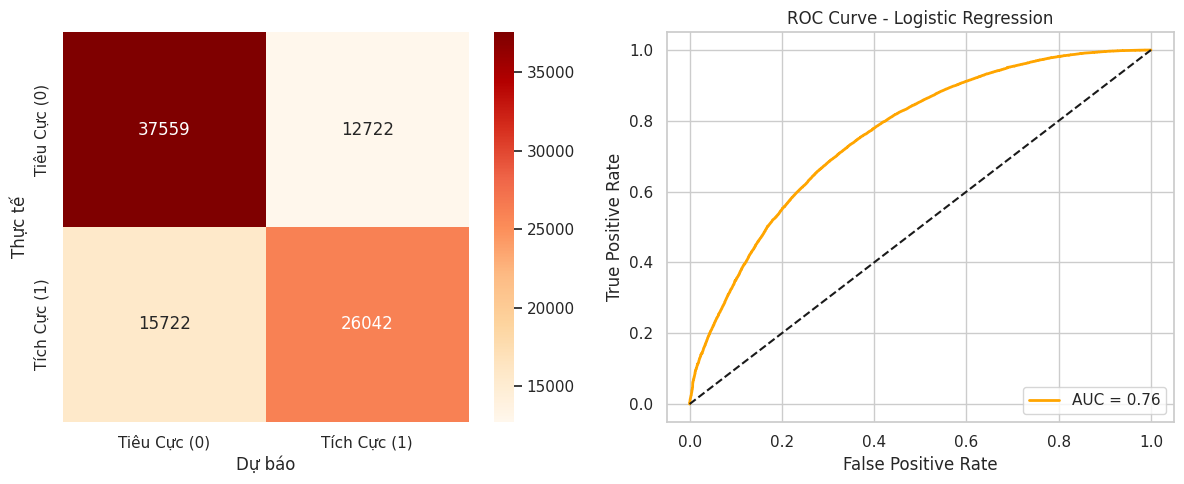

In [12]:
### Ô: Logistic Regression - Huấn luyện và Báo cáo
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.functions import col, regexp_replace, lower
from pyspark.sql.types import DoubleType
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, recall_score

print('--- ĐANG CHẠY: Logistic Regression (LR) ---')
params = {'maxIter':100, 'regParam':0.1, 'elasticNetParam':0.0}
print('Tham số:', params)

# Chuẩn bị dữ liệu nếu chưa có
if 'train_final' not in globals() or 'test_final' not in globals():
    print('Chuẩn bị dữ liệu (assemble + scale) ...')
    features = ["Danceability", "Energy", "Speechiness", "Acousticness", "Instrumentalness", "Liveness"]
    for c in features:
        if c in df.columns:
            df = df.withColumn(c, col(c).cast(DoubleType()))
    assembler = VectorAssembler(inputCols=features, outputCol='features_raw', handleInvalid='skip')
    df_asm = assembler.transform(df)
    scaler = StandardScaler(inputCol='features_raw', outputCol='features', withMean=True, withStd=True)
    scaler_model = scaler.fit(df_asm)
    df_model = scaler_model.transform(df_asm).select('features','sentiment_label')
    train_final, test_final = df_model.randomSplit([0.8,0.2], seed=42)
    print('Prepared train_final/test_final')

# Fit model
lr = LogisticRegression(featuresCol='features', labelCol='sentiment_label', maxIter=100, regParam=0.1)
lr_model = lr.fit(train_final)
print('Mô hình đã huấn luyện:', lr_model)

# Predict & evaluate
preds = lr_model.transform(test_final).select('prediction','probability','sentiment_label')
preds_pd = preds.toPandas()
# probability is a vector; take positive class prob
preds_pd['prob_pos'] = preds_pd['probability'].apply(lambda v: float(v[1]))
y_true = preds_pd['sentiment_label'].astype(int)
y_pred = preds_pd['prediction'].astype(int)
y_prob = preds_pd['prob_pos']

cm = confusion_matrix(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_val = auc(fpr, tpr)
recall = recall_score(y_true, y_pred)
print(f'AUC-ROC: {auc_val:.4f} | Recall: {recall:.4f}')

# Detailed report
print('--- Chi so Confusion Matrix ---')
try:
    TN, FP, FN, TP = cm.ravel()
    print(f'True Negative (TN): {TN}')
    print(f'False Positive (FP): {FP}')
    print(f'False Negative (FN): {FN}')
    print(f'True Positive (TP): {TP}')
except Exception:
    print(cm)
print('--- Báo cáo chi tiết ---')
print(classification_report(y_true, y_pred))

# Plots: Confusion Matrix + ROC
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1,2, figsize=(12,5))
# Heatmap
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='OrRd', cbar=True)
axes[0].set_xlabel('Dự báo')
axes[0].set_ylabel('Thực tế')
axes[0].set_xticklabels(['Tiêu Cực (0)','Tích Cực (1)'])
axes[0].set_yticklabels(['Tiêu Cực (0)','Tích Cực (1)'])
# ROC
axes[1].plot(fpr, tpr, color='orange', lw=2, label=f'AUC = {auc_val:.2f}')
axes[1].plot([0,1],[0,1], color='k', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Logistic Regression')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()



--- ĐANG CHẠY: Decision Tree (DT) ---
Tham số: {'maxDepth': 10, 'minInstancesPerNode': 5}


Mô hình đã huấn luyện: DecisionTreeClassificationModel: uid=DecisionTreeClassifier_fe6bc0271921, depth=10, numNodes=1159, numClasses=2, numFeatures=12
AUC-ROC: 0.7904 | Recall: 0.6741
--- Chi so Confusion Matrix ---
True Negative (TN): 37943
False Positive (FP): 12338
False Negative (FN): 13610
True Positive (TP): 28154
--- Báo cáo chi tiết ---
              precision    recall  f1-score   support

           0       0.74      0.75      0.75     50281
           1       0.70      0.67      0.68     41764

    accuracy                           0.72     92045
   macro avg       0.72      0.71      0.71     92045
weighted avg       0.72      0.72      0.72     92045



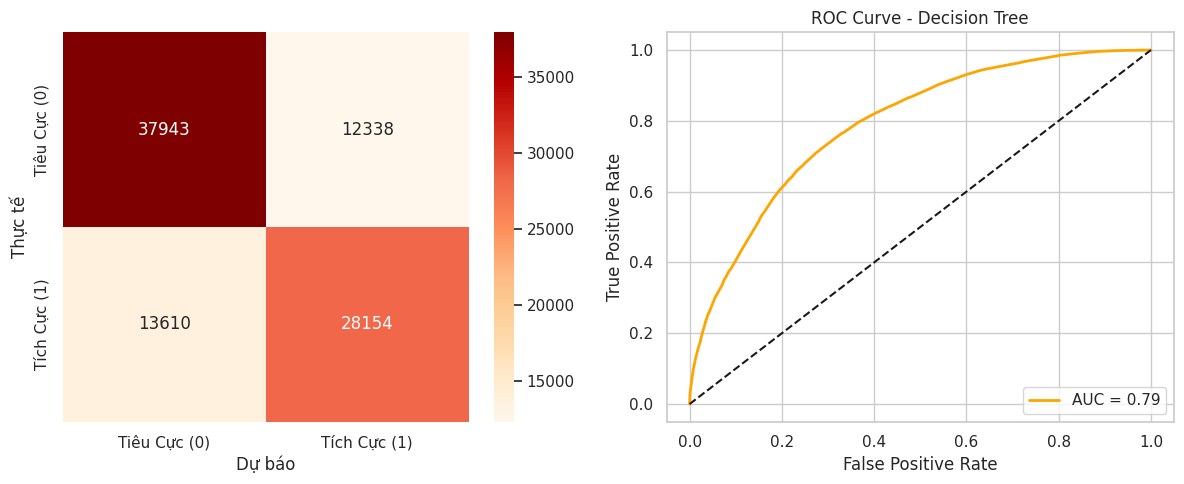

In [13]:
### Ô: Decision Tree - Huấn luyện và Báo cáo
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, recall_score

print('--- ĐANG CHẠY: Decision Tree (DT) ---')
params = {'maxDepth':10, 'minInstancesPerNode':5}
print('Tham số:', params)

# Chuẩn bị dữ liệu nếu chưa có
if 'train_final' not in globals() or 'test_final' not in globals():
    print('Chuẩn bị dữ liệu (assemble + scale) ...')
    features = ["Danceability", "Energy", "Speechiness", "Acousticness", "Instrumentalness", "Liveness"]
    for c in features:
        if c in df.columns:
            df = df.withColumn(c, col(c).cast(DoubleType()))
    assembler = VectorAssembler(inputCols=features, outputCol='features_raw', handleInvalid='skip')
    df_asm = assembler.transform(df)
    scaler = StandardScaler(inputCol='features_raw', outputCol='features', withMean=True, withStd=True)
    scaler_model = scaler.fit(df_asm)
    df_model = scaler_model.transform(df_asm).select('features','sentiment_label')
    train_final, test_final = df_model.randomSplit([0.8,0.2], seed=42)
    print('Prepared train_final/test_final')

# Fit model
dt = DecisionTreeClassifier(featuresCol='features', labelCol='sentiment_label', maxDepth=10, minInstancesPerNode=5, seed=123)
dt_model = dt.fit(train_final)
print('Mô hình đã huấn luyện:', dt_model)

# Predict & evaluate
preds = dt_model.transform(test_final).select('prediction','probability','sentiment_label')
preds_pd = preds.toPandas()
preds_pd['prob_pos'] = preds_pd['probability'].apply(lambda v: float(v[1]))
y_true = preds_pd['sentiment_label'].astype(int)
y_pred = preds_pd['prediction'].astype(int)
y_prob = preds_pd['prob_pos']

cm = confusion_matrix(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_val = auc(fpr, tpr)
recall = recall_score(y_true, y_pred)
print(f'AUC-ROC: {auc_val:.4f} | Recall: {recall:.4f}')

print('--- Chi so Confusion Matrix ---')
try:
    TN, FP, FN, TP = cm.ravel()
    print(f'True Negative (TN): {TN}')
    print(f'False Positive (FP): {FP}')
    print(f'False Negative (FN): {FN}')
    print(f'True Positive (TP): {TP}')
except Exception:
    print(cm)
print('--- Báo cáo chi tiết ---')
print(classification_report(y_true, y_pred))

# Plots
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1,2, figsize=(12,5))
# Heatmap
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='OrRd', cbar=True)
axes[0].set_xlabel('Dự báo')
axes[0].set_ylabel('Thực tế')
axes[0].set_xticklabels(['Tiêu Cực (0)','Tích Cực (1)'])
axes[0].set_yticklabels(['Tiêu Cực (0)','Tích Cực (1)'])
# ROC
axes[1].plot(fpr, tpr, color='orange', lw=2, label=f'AUC = {auc_val:.2f}')
axes[1].plot([0,1],[0,1], color='k', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Decision Tree')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()



--- ĐANG CHẠY: Random Forest (RF) ---
Tham số: {'numTrees': 100, 'maxDepth': 8}


26/05/29 01:10:44 WARN DAGScheduler: Broadcasting large task binary with size 1046.1 KiB
26/05/29 01:10:51 WARN DAGScheduler: Broadcasting large task binary with size 1939.3 KiB
26/05/29 01:10:58 WARN DAGScheduler: Broadcasting large task binary with size 3.7 MiB
26/05/29 01:11:08 WARN DAGScheduler: Broadcasting large task binary with size 1117.4 KiB


Mô hình đã huấn luyện: RandomForestClassificationModel: uid=RandomForestClassifier_403fe768ff0e, numTrees=100, numClasses=2, numFeatures=12


26/05/29 01:11:10 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


AUC-ROC: 0.7909 | Recall: 0.6894
--- Chi so Confusion Matrix ---
True Negative (TN): 37395
False Positive (FP): 12886
False Negative (FN): 12972
True Positive (TP): 28792
--- Báo cáo chi tiết ---
              precision    recall  f1-score   support

           0       0.74      0.74      0.74     50281
           1       0.69      0.69      0.69     41764

    accuracy                           0.72     92045
   macro avg       0.72      0.72      0.72     92045
weighted avg       0.72      0.72      0.72     92045



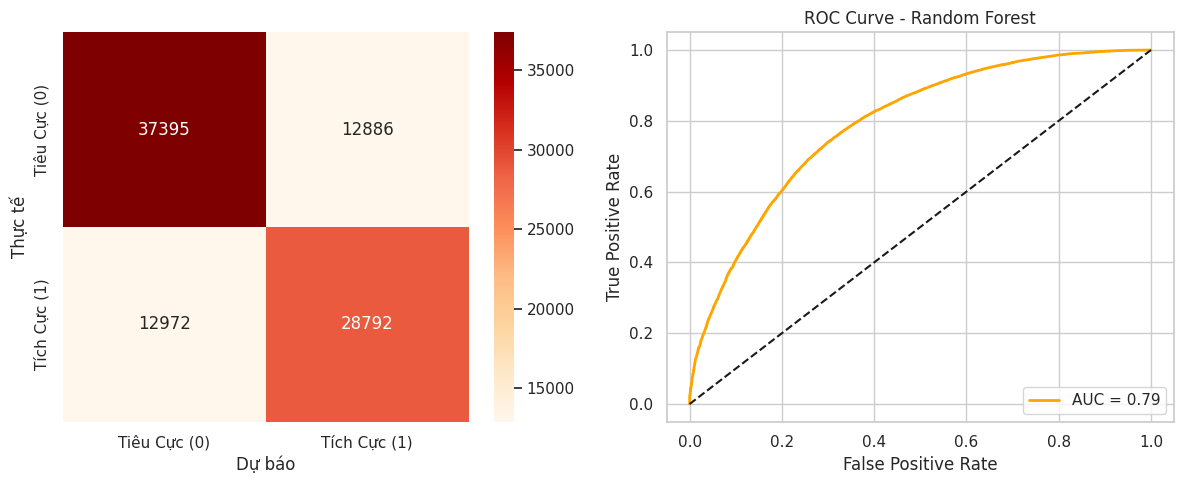

In [14]:
### Ô: Random Forest - Huấn luyện và Báo cáo
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, recall_score

print('--- ĐANG CHẠY: Random Forest (RF) ---')
params = {'numTrees':100, 'maxDepth':8}
print('Tham số:', params)

# Chuẩn bị dữ liệu nếu chưa có
if 'train_final' not in globals() or 'test_final' not in globals():
    print('Chuẩn bị dữ liệu (assemble + scale) ...')
    features = ["Danceability", "Energy", "Speechiness", "Acousticness", "Instrumentalness", "Liveness"]
    for c in features:
        if c in df.columns:
            df = df.withColumn(c, col(c).cast(DoubleType()))
    assembler = VectorAssembler(inputCols=features, outputCol='features_raw', handleInvalid='skip')
    df_asm = assembler.transform(df)
    scaler = StandardScaler(inputCol='features_raw', outputCol='features', withMean=True, withStd=True)
    scaler_model = scaler.fit(df_asm)
    df_model = scaler_model.transform(df_asm).select('features','sentiment_label')
    train_final, test_final = df_model.randomSplit([0.8,0.2], seed=42)
    print('Prepared train_final/test_final')

# Fit model
rf = RandomForestClassifier(featuresCol='features', labelCol='sentiment_label', numTrees=100, maxDepth=8, seed=123)
rf_model = rf.fit(train_final)
print('Mô hình đã huấn luyện:', rf_model)

# Predict & evaluate
preds = rf_model.transform(test_final).select('prediction','probability','sentiment_label')
preds_pd = preds.toPandas()
preds_pd['prob_pos'] = preds_pd['probability'].apply(lambda v: float(v[1]))
y_true = preds_pd['sentiment_label'].astype(int)
y_pred = preds_pd['prediction'].astype(int)
y_prob = preds_pd['prob_pos']

cm = confusion_matrix(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc_val = auc(fpr, tpr)
recall = recall_score(y_true, y_pred)
print(f'AUC-ROC: {auc_val:.4f} | Recall: {recall:.4f}')

print('--- Chi so Confusion Matrix ---')
try:
    TN, FP, FN, TP = cm.ravel()
    print(f'True Negative (TN): {TN}')
    print(f'False Positive (FP): {FP}')
    print(f'False Negative (FN): {FN}')
    print(f'True Positive (TP): {TP}')
except Exception:
    print(cm)
print('--- Báo cáo chi tiết ---')
print(classification_report(y_true, y_pred))

# Plots
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1,2, figsize=(12,5))
# Heatmap
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='OrRd', cbar=True)
axes[0].set_xlabel('Dự báo')
axes[0].set_ylabel('Thực tế')
axes[0].set_xticklabels(['Tiêu Cực (0)','Tích Cực (1)'])
axes[0].set_yticklabels(['Tiêu Cực (0)','Tích Cực (1)'])
# ROC
axes[1].plot(fpr, tpr, color='orange', lw=2, label=f'AUC = {auc_val:.2f}')
axes[1].plot([0,1],[0,1], color='k', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Random Forest')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()



In [ ]:
### 5. Trực quan hóa kết quả (Data Visualization) & Nhận xét
##Chuyển đổi kết quả đánh giá từ Spark DataFrame sang Pandas DataFrame để sử dụng thư viện đồ họa chuyên sâu `Matplotlib` và `Seaborn`.
##Nhận xét kết quả**: (Sau khi chạy xong, bạn nhìn vào chỉ số AUC nào cao hơn để điền nhận xét tương ứng. Thông thường Decision Tree hoặc Random Forest sẽ nhỉnh hơn Logistic Regression do thuộc tính âm thanh có tính phi tuyến tính cao).